In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps

In [3]:
# Definimos el vector de tiempo de 0 a 10 segundos
t = np.linspace(0, 10, 100)
dt = t[1] - t[0]  #el paso (es 0.1)

# Posición x(t) real del sistema (es un muelle)
# x(t) = x0 * exp(-0.5 * t)
x_inicial = 2.0
X = x_inicial * np.exp(-0.5 * t)

#necesito una matriz, no un vector
X = X.reshape(-1, 1) 

print(f"Forma de la matriz de datos X: {X.shape}")

Forma de la matriz de datos X: (100, 1)


In [4]:
# Definimos:
# - Funciones candidatas:(constante, x, x^2) 
# - Optimizador: STLSQ (ns qué operaciones internas hace) con un umbral de 0.05 para descartar términos irrelevantes
modelo = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2),  #polinomios hasta grado 2
    optimizer=ps.STLSQ(threshold=0.05)
)

# Ajustamos el modelo a los datos
modelo.fit(X, t=dt)

# Conclusion
modelo.print()

(x0)' = -0.500 x0


In [5]:
#help(ps.STLSQ)

In [6]:
# Precisión cuantitativa (R^2)
punto_r2 = modelo.score(X, t=dt)
print(f"Coeficiente R^2 del modelo: {punto_r2}")


Coeficiente R^2 del modelo: 0.9999997794109391


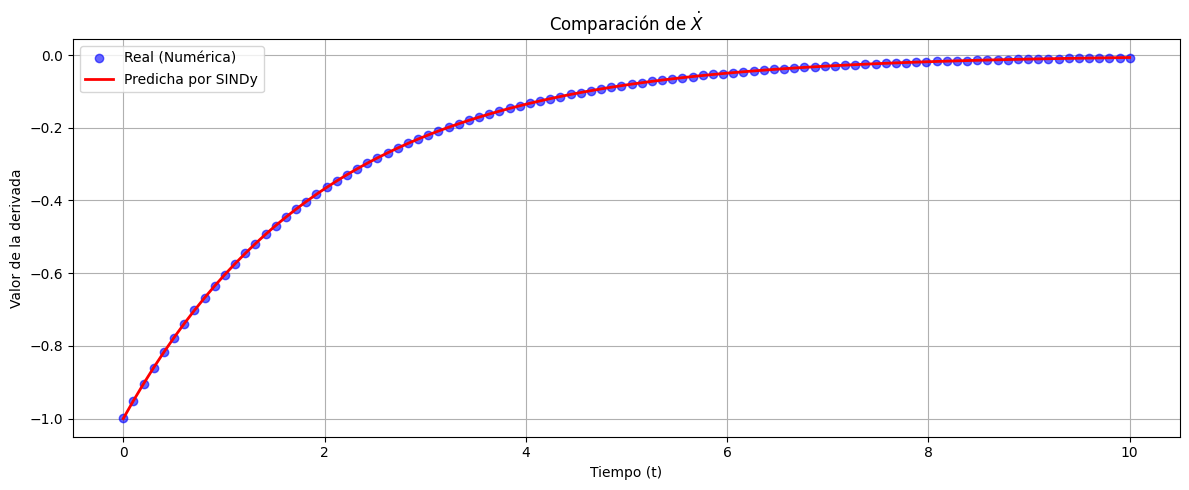

In [7]:
#GRAFICA
#1. Calculamos las derivadas reales que aproximó PySINDy
X_dot_real = modelo.differentiation_method(X, t=dt)

# 2. Predecimos las derivadas usando las ecuaciones descubiertas
X_dot_predicho = modelo.predict(X)

# 3. Graficamos la comparación
plt.figure(figsize=(12, 5))

plt.plot(t, X_dot_real[:, 0], 'o', label='Real (Numérica)', alpha=0.6, color='blue')
plt.plot(t, X_dot_predicho[:, 0], '-', label='Predicha por SINDy', color='red', linewidth=2)
plt.title(r'Comparación de $\dot{X}$') #Asi le pongo un punto a X como en el articulo de Brunson
plt.xlabel('Tiempo (t)')
plt.ylabel('Valor de la derivada')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()